In [33]:
import investos as inv
import pandas as pd
import numpy as np


## Generate Data


In [34]:
from humbldata.core.standard_models.openbbapi.EquityPriceHistoricalQueryParams import (
    EquityPriceHistoricalQueryParams,
)
from humbldata.core.utils.openbb_api_client import OpenBBAPIClient
from humbldata.toolbox.toolbox_helpers import log_returns


async def prepare_actual_returns_for_investos(
    symbols: str = "XLE,XLF,XLU,XLI,XLK,XLV,XLY,XLP,XLRE,XLB,XLC",
    start_date: str = "2018-06-20", # XLC starts on 2018-06-20
    end_date: str = "2025-09-16",
    provider: str = "yfinance",
    adjustment: str = "splits_and_dividends",
) -> pd.DataFrame:
    api_query_params = EquityPriceHistoricalQueryParams(
        symbol=symbols,
        start_date=start_date,
        end_date=end_date,
        provider=provider,
        adjustment=adjustment,
    )
    api_client = OpenBBAPIClient()
    api_response = await api_client.fetch_data(
        obb_path="equity.price.historical",
        api_query_params=api_query_params,
    )
    equity_historical_data = api_response.to_polars(collect=False)
    log_returns_df = log_returns(equity_historical_data, _column_name="close")
    log_returns_pd = log_returns_df.collect().to_pandas()
    log_returns_pivot = log_returns_pd.pivot(index="date", columns="symbol", values="log_returns")
    log_returns_pivot_clean = log_returns_pivot.dropna().copy()
    log_returns_pivot_clean.loc[:, "cash"] = 0.0
    return log_returns_pivot_clean

# Example usage in notebook:
actual_returns = await prepare_actual_returns_for_investos()
actual_returns


INFO: OpenBBAPIClient || START: fetch_data (async)
INFO: OpenBBAPIClient || Prepared request for: https://data.humblfinance.io/api/v1/equity/price/historical?provider=yfinance&symbol=XLE,XLF,XLU,XLI,XLK,XLV,XLY,XLP,XLRE,XLB,XLC&start_date=2018-06-20&end_date=2025-09-16&adjustment=splits_and_dividends
INFO: RateLimiter || Checking Rate Limits for Provider: yfinance Route: /equity/price/historical | 10/10 remaining (resets at 2025-09-16T14:31:50.237528)
INFO: RateLimiter || Updating Rate Limit - Provider: yfinance Route: /equity/price/historical | 9/10 remaining (resets at 2025-09-16T14:31:50.237528)
INFO: OpenBBAPIClient || Fetching data from: https://data.humblfinance.io/api/v1/equity/price/historical?provider=yfinance&symbol=XLE,XLF,XLU,XLI,XLK,XLV,XLY,XLP,XLRE,XLB,XLC&start_date=2018-06-20&end_date=2025-09-16&adjustment=splits_and_dividends
INFO: OpenBBAPIClient || END: fetch_data (async) - Total time: 7.1748s


symbol,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,cash
date,,,,,,,,,,,,
2018-06-21,-0.010691,-0.006148,-0.018690,-0.002937,-0.012634,-0.007713,0.001955,0.005950,0.003379,-0.005779,-0.007149,0.0
2018-06-22,0.014458,0.004367,0.019755,-0.004791,0.003449,-0.003244,0.008168,0.008704,0.006921,0.004485,-0.001705,0.0
2018-06-25,-0.015672,-0.020813,-0.020298,-0.010771,-0.012751,-0.020981,0.005023,-0.002479,0.016416,-0.009227,-0.021979,0.0
2018-06-26,0.003812,0.001657,0.012550,-0.003367,0.003759,0.004030,-0.004249,0.005261,0.001163,-0.003095,0.007137,0.0
2018-06-27,-0.003118,-0.008760,0.013321,-0.012441,-0.008093,-0.013741,-0.002131,-0.002782,0.004829,-0.008499,-0.013031,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-10,0.001876,-0.007388,0.017319,-0.003380,0.007361,0.017965,-0.009834,-0.000478,0.017044,-0.009133,-0.012037,0.0
2025-09-11,0.020730,0.015238,0.000224,0.016233,0.009469,0.003363,0.008098,0.016114,0.005304,0.017254,0.019266,0.0
2025-09-12,-0.010093,0.008300,-0.005964,-0.004266,-0.008016,-0.000664,-0.003356,-0.004476,0.005042,-0.011590,0.005168,0.0


In [35]:
from humbldata.toolbox.toolbox_controller import Toolbox

toolbox = Toolbox(
    symbols=["XLE", "XLF", "XLU", "XLI", "XLK", "XLV", "XLY", "XLP", "XLRE", "XLB", "XLC"],
    start_date="2018-06-20",
    end_date="2025-09-16",
    membership="admin",
)
humbl_compass = await toolbox.fundamental.humbl_compass(country="united_states", z_score="3m")
metric_to_rank = humbl_compass.to_pandas()
metric_to_rank

INFO: HumblCompassFetcher || START: fetch_data (async)
INFO: LogCacheHitPlugin || humbl_compass cache HIT & RETURNED [remote redis]
DEBUG: LogCacheHitPlugin || humbl_compass cache key: {"country": "united_states", "end_date": "2025-09-16", "start_date": "2018-06-20", "z_score": "3m"} [remote redis]
INFO: HumblCompassFetcher || END: fetch_data (async) - Total time: 0.0193s


,date_month_start,country,cpi,cpi_3m_delta,cli,cli_3m_delta,humbl_regime,cpi_zscore,cli_zscore
0,2018-03-01,United States,2.36,0.25,100.89,0.33,humblBOUNCE,1.01,0.92
1,2018-04-01,United States,2.46,0.39,100.92,0.22,humblBOUNCE,0.94,0.80
2,2018-05-01,United States,2.80,0.59,100.90,0.08,humblBOUNCE,1.13,-0.27
3,2018-06-01,United States,2.87,0.51,100.85,-0.04,humblBLOAT,0.73,-1.12
4,2018-07-01,United States,2.95,0.49,100.77,-0.14,humblBLOAT,1.02,-1.07
...,...,...,...,...,...,...,...,...,...
85,2025-04-01,United States,2.31,-0.69,100.23,-0.11,humblBUST,-0.72,-0.98
86,2025-05-01,United States,2.35,-0.47,100.24,-0.09,humblBUST,0.07,-0.42
87,2025-06-01,United States,2.67,0.28,100.29,0.01,humblBOUNCE,1.15,1.15
88,2025-07-01,United States,2.70,0.39,100.35,0.12,humblBOUNCE,0.67,1.03


In [36]:
metric_to_rank = humbl_compass.to_pandas()

In [37]:
metric_to_rank

,date_month_start,country,cpi,cpi_3m_delta,cli,cli_3m_delta,humbl_regime,cpi_zscore,cli_zscore
0,2018-03-01,United States,2.36,0.25,100.89,0.33,humblBOUNCE,1.01,0.92
1,2018-04-01,United States,2.46,0.39,100.92,0.22,humblBOUNCE,0.94,0.80
2,2018-05-01,United States,2.80,0.59,100.90,0.08,humblBOUNCE,1.13,-0.27
3,2018-06-01,United States,2.87,0.51,100.85,-0.04,humblBLOAT,0.73,-1.12
4,2018-07-01,United States,2.95,0.49,100.77,-0.14,humblBLOAT,1.02,-1.07
...,...,...,...,...,...,...,...,...,...
85,2025-04-01,United States,2.31,-0.69,100.23,-0.11,humblBUST,-0.72,-0.98
86,2025-05-01,United States,2.35,-0.47,100.24,-0.09,humblBUST,0.07,-0.42
87,2025-06-01,United States,2.67,0.28,100.29,0.01,humblBOUNCE,1.15,1.15
88,2025-07-01,United States,2.70,0.39,100.35,0.12,humblBOUNCE,0.67,1.03


In [38]:
_compass = metric_to_rank.copy()
if "date_month_start" in _compass.columns:
    _compass = _compass.rename(columns={"date_month_start": "date"})

_compass["date"] = pd.to_datetime(_compass["date"])
_compass = _compass.sort_values("date").set_index("date")

signal_dates = (_compass.index + pd.offsets.MonthBegin(1))
regime_signal = pd.Series(
    _compass["humbl_regime"].values, index=signal_dates, name="humbl_regime"
).sort_index()

trading_index = pd.to_datetime(actual_returns.index)
signal_dates_in_market = pd.Index([d for d in regime_signal.index if d in trading_index])
regime_signal = regime_signal.loc[signal_dates_in_market]

regime_daily = regime_signal.reindex(trading_index).ffill()

print("Signal dates (head):\n", regime_signal.head())
print("Daily regime coverage: ", regime_daily.notna().mean().round(4))

Signal dates (head):
 2018-08-01    humblBLOAT
2018-10-01     humblBUST
2018-11-01     humblBUST
2019-02-01     humblBUST
2019-03-01     humblBUST
Name: humbl_regime, dtype: object
Daily regime coverage:  0.9846


In [39]:
# 2) Aggregate daily returns into monthly trading periods keyed by signal_dates
assets = [c for c in actual_returns.columns if c != "cash"]
periods = list(regime_signal.index)
period_rets = []

for i in range(len(periods) - 1):
    s, e = periods[i], periods[i + 1]
    block = actual_returns.loc[(actual_returns.index >= s) & (actual_returns.index < e), assets]
    if block.empty:
        continue
    r_block = (block + 1.0).prod() - 1.0
    r_block["cash"] = 0.0
    r_block.name = s
    period_rets.append(r_block)

actual_returns_m = pd.DataFrame(period_rets).sort_index()
print(actual_returns_m.head())

symbol           XLB       XLC       XLE       XLF       XLI       XLK  \
2018-08-01 -0.026782  0.012827 -0.012840 -0.009855  0.023296  0.064867   
2018-10-01 -0.094041 -0.064748 -0.116165 -0.049547 -0.111041 -0.084940   
2018-11-01  0.013662 -0.003209 -0.050547 -0.012795  0.025538 -0.051701   
2019-02-01  0.031051 -0.005230  0.022080  0.021793  0.063189  0.068551   
2019-03-01  0.011680  0.019682  0.019933 -0.026634 -0.012200  0.046501   

symbol           XLP      XLRE       XLU       XLV       XLY  cash  
2018-08-01  0.012992 -0.004055  0.005075  0.073702  0.055787   0.0  
2018-10-01  0.018534 -0.017907  0.018215 -0.069828 -0.103982   0.0  
2018-11-01 -0.023807  0.077388  0.024767  0.020599  0.027536   0.0  
2019-02-01  0.017551  0.010782  0.040849  0.010410  0.012697   0.0  
2019-03-01  0.037922  0.049038  0.027540  0.003953  0.035835   0.0  


In [40]:
# 3) Build expanding, regime-conditional scores without look-ahead
min_obs = 20
assets = [c for c in actual_returns.columns if c != "cash"]
metric_rows = {}
periods = list(actual_returns_m.index)

for i in range(1, len(periods) - 1):
    s = periods[i]  # score date
    r = regime_signal.loc[s]

    prev_mask = actual_returns.index < s
    mask_r = (regime_daily == r) & prev_mask

    rets_hist = actual_returns.loc[mask_r, assets]
    counts = rets_hist.notna().sum()
    mean_r = rets_hist.mean()

    uncond = actual_returns.loc[prev_mask, assets].mean()
    score = mean_r.where(counts >= min_obs, uncond)

    score.name = s
    metric_rows[s] = score

metric_to_rank_m = (
    pd.DataFrame(metric_rows).T
    .reindex(actual_returns_m.index)
    .ffill()
)

print(metric_to_rank_m.head())

symbol           XLB       XLC       XLE       XLF       XLI       XLK  \
2018-08-01       NaN       NaN       NaN       NaN       NaN       NaN   
2018-10-01 -0.000023 -0.000415  0.000225  0.000219  0.001034  0.000778   
2018-11-01 -0.004188 -0.002709 -0.005227 -0.002099 -0.005002 -0.003628   
2019-02-01 -0.000903 -0.000680 -0.001935 -0.000656 -0.000979 -0.001472   
2019-03-01 -0.000432 -0.000599 -0.001357 -0.000320 -0.000199 -0.000552   

symbol           XLP      XLRE       XLU       XLV       XLY  
2018-08-01       NaN       NaN       NaN       NaN       NaN  
2018-10-01  0.000868  0.000491  0.000800  0.001660  0.000654  
2018-11-01  0.000862 -0.000699  0.000850 -0.003052 -0.004630  
2019-02-01 -0.000011  0.000751  0.000568 -0.000520 -0.000843  
2019-03-01  0.000162  0.000719  0.000855 -0.000320 -0.000561  


In [71]:
# 4) Run monthly backtest with RankLongShort (n_periods_held=1)
from investos.portfolio import BacktestController
from investos.portfolio.strategy.rank_long_short import RankLongShort

strategy = RankLongShort(
    actual_returns=actual_returns_m,
    metric_to_rank=metric_to_rank_m.drop(columns=["cash"], errors="ignore"),
    n_periods_held=1,
    leverage=1.2,
    percent_long=0.3,
    percent_short=0.1,
    ratio_long=150,
    ratio_short=30,
    costs=[],
    cash_column_name="cash",
)

bt = BacktestController(strategy, time_periods=actual_returns_m.index, aum=100_000)
results = bt.generate_positions()
results.summary  # object with h (holdings), u (trades), etc.

Generating historical portfolio trades and positions at 2025-09-16 14:55:44...


Done simulating at 2025-09-16 14:55:44.
Initial timestamp                         2018-08-01 00:00:00
Final timestamp                           2025-07-01 00:00:00
Total portfolio return (%)                            189.95%
Annualized portfolio return (%)                        16.64%
Annualized excess portfolio return (%)                 16.64%
Annualized excess risk (%)                             13.49%
Information ratio (x)                                   1.23x
Annualized risk over risk-free (%)                     13.49%
Sharpe ratio (x)                                        1.23x
Max drawdown (%)                                       11.01%
Annual turnover (x)                                     7.06x
Portfolio hit rate (%)                                 68.52%


<Axes: >

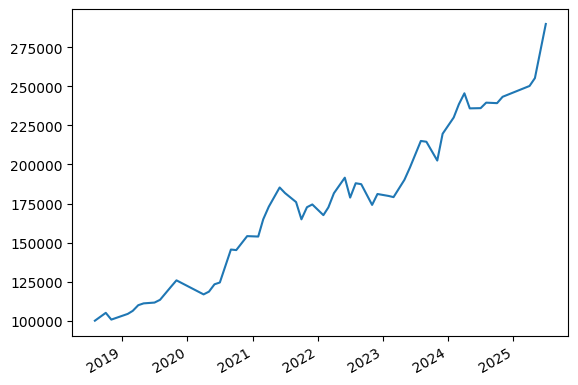

In [72]:
results.v.plot()

In [73]:
results.trades

symbol,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,cash
2018-08-01,-20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33333.333333,33333.333333,33333.333333,-80000.000000
2018-10-01,19464.355624,-21004.223046,0.000000,0.000000,35007.038410,0.000000,35007.038410,0.000000,-33502.506440,-783.027563,-35192.898440,1004.223046
2018-11-01,0.000000,19644.245036,-20139.651076,0.000000,-31119.831832,0.000000,-2089.780038,33566.085127,33566.085127,-32562.580374,0.000000,-864.571970
2019-02-01,0.000000,0.000000,-1747.574740,0.000000,0.000000,0.000000,2015.051148,-1381.656288,384.611364,0.000000,0.000000,729.568516
2019-03-01,0.000000,0.000000,71.684739,0.000000,0.000000,0.000000,38.035277,273.490362,-772.313025,0.000000,0.000000,389.102646
2019-04-01,0.000000,0.000000,-302.853251,0.000000,0.000000,0.000000,-132.579270,-526.429447,235.259728,0.000000,0.000000,726.602240
2019-05-01,-22217.491441,0.000000,21960.619297,0.000000,0.000000,37029.152402,-37676.991434,-36419.296884,-36966.863706,37029.152402,37029.152402,232.566962
2019-07-01,22695.985992,0.000000,-22318.923465,0.000000,0.000000,-36711.552824,37198.205774,37198.205774,37198.205774,-38547.881673,-36813.677377,101.432023
2019-08-01,0.000000,0.000000,-721.108863,0.000000,0.000000,0.000000,-258.458132,-30.599681,655.751233,0.000000,0.000000,354.415443
2019-10-01,0.000000,0.000000,-2840.808793,0.000000,0.000000,40564.671365,-39222.729094,-39940.309872,-41355.630247,40564.671365,40564.671365,1665.463911


## Testing Currnet/Next Period Positions

Model: GPT-5, 32B, Code Assistant, revision 2025-09-01

### What this code does
- Builds a monthly, no-look-ahead regime signal from `humbl_compass` (month M becomes tradable on MonthBegin(M+1)).
- Converts daily `actual_returns` into period returns between consecutive signal dates.
- Computes out-of-sample, regime-conditional scores per asset to rank longs and shorts.
- Runs `RankLongShort` monthly on those dates, then produces trades and target holdings you can execute.

### Key variables
- **metric_to_rank**: raw compass output. We only use `date_month_start` and `humbl_regime`.
- **regime_signal**: Series indexed by `MonthBegin(M+1)` containing the regime to trade at that date.
- **regime_daily**: regime label forward-filled to the trading calendar for training masks.
- **actual_returns**: daily log returns for assets plus `cash=0`.
- **actual_returns_m**: monthly period returns aligned to `regime_signal` dates.
- **metric_to_rank_m**: DataFrame of per-asset scores at each signal date, computed strictly from returns before that date and only within matching past regime episodes (with fallback to unconditional mean when history is thin).
- **strategy**: `RankLongShort(actual_returns=actual_returns_m, metric_to_rank=metric_to_rank_m, n_periods_held=1, ...)`.
- **bt**: `BacktestController(strategy, time_periods=actual_returns_m.index)` that drives the monthly simulation.
- **results**: backtest outputs:
  - `results.u.loc[t]`: dollar trades at start of period t.
  - `results.h.loc[t]`: holdings after returns of period t.
- **u_next**: trades to place at the next signal date given current holdings.
- **h_target_next**: pre-return target holdings for the next signal date.
- **w_target_next**: target weights implied by `h_target_next`.

### How it integrates with InvestOS
- You pass monthly `actual_returns_m` and numeric `metric_to_rank_m` into `RankLongShort`. That class:
  - Picks top `percent_long` assets to long and bottom `percent_short` to short using `metric_to_rank_m.loc[t]`.
  - Normalizes weights, sizes trades off portfolio equity and `leverage`, and optionally unwinds old tranches.
- `BacktestController` injects itself into the strategy, loops over `time_periods` (your signal dates), calls:
  - `strategy.generate_trade_list(h, t)` to get dollar trades,
  - `strategy.get_actual_positions_for_t(h, u, t)` to apply costs, update cash, and realize returns,
  - then saves `u` and `h` into `results`.
- Live usage:
  - On the first business day of a new month, compute the new score row from past data only, append to `metric_to_rank_m`, set `strategy.metric_to_rank`, then call `strategy.generate_trade_list(h_curr, t_today)` to get executable dollar trades. Convert to shares with live prices.

### Why it avoids look-ahead
- Regime month M is only tradable at MonthBegin(M+1).
- Scores at date s use only returns with date < s and only from prior occurrences of the same regime.
- The backtest rebalances exclusively on those signal dates with `n_periods_held=1`.

In [49]:
# use next-period returns aligned to current t
next_period = actual_returns_m.shift(-1)

rows = []
for t in metric_to_rank_m.index:
    if t not in next_period.index:
        continue
    r_next = next_period.loc[t]
    if r_next.isna().all():
        continue  # last row or missing block
    longs, shorts = bucket_indices(metric_to_rank_m.loc[t].dropna())
    rows.append({
        "t": t,
        "long_next": r_next.get(longs, pd.Series()).mean(),
        "short_next": r_next.get(shorts, pd.Series()).mean(),
        "ls_next": r_next.get(longs, pd.Series()).mean() - r_next.get(shorts, pd.Series()).mean(),
    })

bucket_eval = pd.DataFrame(rows).set_index("t")
print(bucket_eval.describe(percentiles=[0.1, 0.5, 0.9]))

       long_next  short_next    ls_next
count  53.000000   53.000000  53.000000
mean    0.018276    0.007038   0.011238
std     0.048081    0.078877   0.061369
min    -0.124529   -0.360199  -0.124331
10%    -0.035119   -0.063696  -0.059887
50%     0.016363    0.013241   0.015609
90%     0.072132    0.090282   0.080046
max     0.147545    0.180170   0.235670


In [56]:
t = results.u.index[-1]
u_t = results.u.loc[t].sort_values()
u_t  # dollars to buy/sell at start of t (cash is negative of non-cash plus costs)

symbol
XLK    -6038.308117
XLE    -4059.721607
XLC     -624.833696
XLB        0.000000
XLF        0.000000
XLI        0.000000
XLP        0.000000
XLRE       0.000000
XLU        0.000000
XLV        0.000000
XLY     2500.835604
cash    8222.027816
Name: 2025-07-01 00:00:00, dtype: float64

In [57]:
idx = results.h.index
prev_t, t = idx[-2], idx[-1]
h_start = results.h.loc[prev_t]      # holdings coming into t
u_t = results.u.loc[t]
h_target = (h_start + u_t).sort_values()
h_target

symbol
XLE    -5.097867e+04
XLV    -1.405849e-11
XLB     0.000000e+00
XLF     0.000000e+00
XLP     0.000000e+00
XLRE    0.000000e+00
XLU     0.000000e+00
XLI     1.444095e-11
cash    6.969598e+04
XLK     7.389366e+04
XLC     7.778970e+04
XLY     8.143477e+04
dtype: float64

In [59]:
h_end = results.h.loc[t]
h_end

symbol
XLB     0.000000e+00
XLC     9.315999e+04
XLE    -6.000308e+04
XLF     0.000000e+00
XLI     1.625620e-11
XLK     9.857347e+04
XLP     0.000000e+00
XLRE    0.000000e+00
XLU     0.000000e+00
XLV    -1.351026e-11
XLY     9.003432e+04
cash    6.295886e+04
Name: 2025-07-01 00:00:00, dtype: float64

In [60]:
w_target = (h_target / h_target.sum()).sort_values()
w_target

symbol
XLE    -2.024285e-01
XLV    -5.582411e-17
XLB     0.000000e+00
XLF     0.000000e+00
XLP     0.000000e+00
XLRE    0.000000e+00
XLU     0.000000e+00
XLI     5.734280e-17
cash    2.767521e-01
XLK     2.934204e-01
XLC     3.088910e-01
XLY     3.233650e-01
dtype: float64

In [61]:
cash = "cash"
h_non_cash = h_target.drop(cash, errors="ignore")
longs = h_non_cash[h_non_cash > 0].sort_values(ascending=False)
shorts = h_non_cash[h_non_cash < 0].sort_values()
longs, shorts

(symbol
 XLY    8.143477e+04
 XLC    7.778970e+04
 XLK    7.389366e+04
 XLI    1.444095e-11
 dtype: float64,
 symbol
 XLE   -5.097867e+04
 XLV   -1.405849e-11
 dtype: float64)

In [63]:
from pandas.tseries.offsets import MonthBegin

# 1) Determine next signal date and regime label to use
t_next = results.h.index[-1] + MonthBegin(1)
assert t_next not in metric_to_rank_m.index, "Already present"

# regime at t_next is the label that becomes tradable on t_next
r_next = regime_signal.reindex([t_next]).iloc[0]

# 2) Build score at t_next strictly from past
assets = [c for c in actual_returns.columns if c != "cash"]
prev_mask = actual_returns.index < t_next
mask_r = (regime_daily == r_next) & prev_mask

rets_hist = actual_returns.loc[mask_r, assets]
counts = rets_hist.notna().sum()
mean_r = rets_hist.mean()

# fallback if thin history for an asset
min_obs = 20
uncond = actual_returns.loc[prev_mask, assets].mean()
score_next = mean_r.where(counts >= min_obs, uncond)

# 3) Append to metric_to_rank_m and to the live strategy copy
score_next.name = t_next
metric_to_rank_m.loc[t_next, score_next.index] = score_next
metric_to_rank_m.sort_index(inplace=True)

# The strategy holds its own reference; update it
strategy.metric_to_rank = metric_to_rank_m.drop(columns=["cash"], errors="ignore")

In [64]:
h_curr = results.h.iloc[-1]                  # end of last period (your current holdings)
u_next = strategy.generate_trade_list(h_curr, t_next)  # dollars to trade now at start of t_next

# Target holdings to execute now (pre-returns)
h_target_next = (h_curr + u_next).sort_values()

# Optional: weights for allocator view
w_target_next = (h_target_next / h_target_next.sum()).sort_values()

u_next.sort_values(), w_target_next

(symbol
 XLY    -94212.260918
 XLC    -91535.394771
 XLV    -64062.801674
 XLK     -3429.312447
 XLB         0.000000
 XLP         0.000000
 XLRE        0.000000
 XLU         0.000000
 XLE     65788.560848
 XLF     92535.157974
 XLI     92535.157974
 dtype: float64,
 symbol
 XLV    -0.292012
 XLY    -0.019044
 XLB     0.000000
 XLP     0.000000
 XLRE    0.000000
 XLU     0.000000
 XLC     0.007405
 XLE     0.026372
 XLF     0.421796
 XLI     0.421796
 XLK     0.433688
 cash         NaN
 dtype: float64)